## Pedersen (Senseval2) validation

This notebook valudates the use of the semantic features for analyzing polysemy.

## 0. Preamble

In [1]:
import nltk
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, v_measure_score, normalized_mutual_info_score, homogeneity_score, completeness_score
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful!")

All imports successful!


## 1. Load Data

In [2]:
 # load pedersen sense-tagged corpus
fileids = [
    'hard.pos',
    'line.pos',
    'interest.pos',
    'serve.pos',
]
root = '/home/gsc685/data/pedersen_sense_tagged/'
corpus = nltk.corpus.reader.senseval.SensevalCorpusReader(root, fileids=fileids)
instances = corpus.instances()

print("first row of data")
print(instances[0])
print("number of instances:", len(instances))
words = ' '.join([word for (word, pos) in instances[0].context])
print("words in first sentence: ", words)

first row of data
SensevalInstance(word='hard-a', position=20, context=[('``', '``'), ('he', 'PRP'), ('may', 'MD'), ('lose', 'VB'), ('all', 'DT'), ('popular', 'JJ'), ('support', 'NN'), (',', ','), ('but', 'CC'), ('someone', 'NN'), ('has', 'VBZ'), ('to', 'TO'), ('kill', 'VB'), ('him', 'PRP'), ('to', 'TO'), ('defeat', 'VB'), ('him', 'PRP'), ('and', 'CC'), ('that', 'DT'), ("'s", 'VBZ'), ('hard', 'JJ'), ('to', 'TO'), ('do', 'VB'), ('.', '.'), ("''", "''")], senses=('HARD1',))
number of instances: 15225
words in first sentence:  `` he may lose all popular support , but someone has to kill him to defeat him and that 's hard to do . ''


In [3]:
# convert to pandas dataframe
# you want data in this format: word | word_form | sentence | pos | position | sense
def get_data(instances):
    data = []
    for instance in instances:
        try:
            word = instance.word
            word_form = instance.context[instance.position][0]
            try:
                sentence = ' '.join([word for (word, pos) in instance.context])
            except:
                stripped_instance = [item for item in instance.context if isinstance(item, tuple)]
                sentence = ' '.join([word for (word, pos) in stripped_instance])
            pos = instance.context[instance.position][1]
            position = instance.position
            sense = instance.senses[0]
            data.append((word, word_form, sentence, pos, position, sense))
        except Exception as e:
            print(f"Error processing instance: {e}")
            continue
    return data

data = get_data(instances)
print("data in this format: word | word_form | sentence | pos | position | sense")
print(data[0])
pedersen_df = pd.DataFrame(data, columns=['word', 'word_form', 'sentence', 'pos', 'position', 'sense'])

pedersen_df.head(5)

data in this format: word | word_form | sentence | pos | position | sense
('hard-a', 'hard', "`` he may lose all popular support , but someone has to kill him to defeat him and that 's hard to do . ''", 'JJ', 20, 'HARD1')


,word,word_form,sentence,pos,position,sense
0,hard-a,hard,"`` he may lose all popular support , but someo...",JJ,20,HARD1
1,hard-a,hard,clever white house `` spin doctors '' are havi...,JJ,10,HARD1
2,hard-a,hard,i find it hard to believe that the sacramento ...,JJ,3,HARD1
3,hard-a,hard,now when you get bad credit data or are confus...,JJ,15,HARD1
4,hard-a,harder,'a great share of responsibility for this nati...,JJ,66,HARD1


In [4]:
# sense distribution
pedersen_df.groupby(['word', 'sense']).size()

word        sense     
hard-a      HARD1         3455
            HARD2          502
            HARD3          376
interest-n  interest_1     361
            interest_2      11
            interest_3      66
            interest_4     178
            interest_5     500
            interest_6    1252
line-n      cord           373
            division       374
            formation      349
            phone          429
            product       2217
            text           404
serve-v     SERVE10       1814
            SERVE12       1272
            SERVE2         853
            SERVE6         439
dtype: int64

## 2. Load Features and Perform Validation


In [5]:
# what is the shape of the feature data and how does it join to the token data?
features_path = f'/home/gsc685/data/features/senseval2/interest-n_feature_vectors_roberta_binder_layer7.csv'
features_df = pd.read_csv(features_path)
print(f"Loaded {len(features_df)} feature rows")
features_df

Loaded 148655 feature rows


,Unnamed: 0,cluster,feature,predicted_value,token_id,word
0,0,1,Angry,3.786444,8479,interest-n
1,1,1,Arousal,1.236612,8479,interest-n
2,2,1,Attention,1.415556,8479,interest-n
3,3,1,Audition,2.756609,8479,interest-n
4,4,1,Away,2.092192,8479,interest-n
...,...,...,...,...,...,...
148650,148650,2,Toward,1.035716,10846,interest-n
148651,148651,2,Unpleasant,2.301296,10846,interest-n
148652,148652,2,UpperLimb,2.869952,10846,interest-n
148653,148653,2,Vision,2.319892,10846,interest-n


note: features.token_id corresponds to the index column of the pedersen_df

In [6]:
# add the index as token_id in pedersen_df
pedersen_df = pedersen_df.reset_index().rename(columns={'index': 'token_id'})
pedersen_df.head(5)

,token_id,word,word_form,sentence,pos,position,sense
0,0,hard-a,hard,"`` he may lose all popular support , but someo...",JJ,20,HARD1
1,1,hard-a,hard,clever white house `` spin doctors '' are havi...,JJ,10,HARD1
2,2,hard-a,hard,i find it hard to believe that the sacramento ...,JJ,3,HARD1
3,3,hard-a,hard,now when you get bad credit data or are confus...,JJ,15,HARD1
4,4,hard-a,harder,'a great share of responsibility for this nati...,JJ,66,HARD1


In [8]:

# Dictionary to store results
validation_results = []

# Lemmas to validate
lemmas = ['hard-a', 'interest-n', 'line-n', 'serve-v']

for lemma in lemmas:
    print(f"\n{'='*60}")
    print(f"Processing: {lemma}")
    print(f"{'='*60}")
    
    # 1. Load features for this lemma
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_binder_layer7.csv'
    features_df = pd.read_csv(features_path)
    print(f"Loaded {len(features_df)} feature rows")
    
    # 2. Get subset of pedersen_df for this lemma
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    print(f"Found {len(lemma_data)} instances in pedersen_df")
    
    # 3. Get number of senses for this lemma
    n_senses = lemma_data['sense'].nunique()
    sense_counts = lemma_data.groupby('sense').size()
    print(f"Number of gold senses: {n_senses}")
    print(f"Sense distribution:\n{sense_counts}")
    
    # 4. Transform features into feature vectors (pivot wide format)
    # Each row should be a token_id with all feature values as columns
    print(f"\nTransforming to feature vectors...")
    
    # # Check if token_id exists, otherwise create it from index
    # if 'token_id' not in features_df.columns:
    #     # Assuming features are grouped by instance (each instance has 3981 features)
    #     features_df['token_id'] = features_df.index // 3981
    
    # Pivot to wide format: rows=token_id, columns=feature, values=predicted_value
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    print(f"Feature matrix shape: {feature_matrix.shape}")
    
    # Handle any NaN values
    # feature_matrix = feature_matrix.fillna(0)
    
    # 5. Add token_id to lemma_data if not present
    #if 'token_id' not in lemma_data.columns:
    #    lemma_data['token_id'] = range(len(lemma_data))
    
    # Ensure we have matching data
    # Keep only tokens that appear in both datasets
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    print(f"Common tokens between features and gold data: {len(common_token_ids)}")
    
    # Filter both dataframes
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')
    
    # 6. Cluster using k=n_senses
    print(f"\nClustering with k={n_senses}...")
    kmeans = KMeans(n_clusters=n_senses, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(feature_matrix_filtered)
    
    # 7. Get gold sense labels
    true_labels = lemma_data_filtered['sense'].values
    
    # 8. Calculate metrics
    ari = adjusted_rand_score(true_labels, cluster_labels)
    v_measure = v_measure_score(true_labels, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)
    homogeneity = homogeneity_score(true_labels, cluster_labels)
    completeness = completeness_score(true_labels, cluster_labels)
    
    print(f"\nValidation Metrics:")
    print(f"  Adjusted Rand Index:  {ari:.3f}")
    print(f"  V-measure:            {v_measure:.3f}")
    print(f"  NMI:                  {nmi:.3f}")
    print(f"  Homogeneity:          {homogeneity:.3f}")
    print(f"  Completeness:         {completeness:.3f}")
    
    # Store results
    validation_results.append({
        'lemma': lemma,
        'n_instances': len(lemma_data_filtered),
        'n_gold_senses': n_senses,
        'n_clusters': n_senses,
        'n_features': feature_matrix_filtered.shape[1],
        'ARI': ari,
        'V-measure': v_measure,
        'NMI': nmi,
        'Homogeneity': homogeneity,
        'Completeness': completeness
    })
    
    # Create confusion matrix
    confusion = pd.crosstab(
        pd.Series(true_labels, name='Gold Sense'),
        pd.Series(cluster_labels, name='Predicted Cluster'),
        margins=True
    )
    print(f"\nConfusion Matrix:")
    print(confusion)

print(f"\n{'='*60}")
print("VALIDATION COMPLETE")
print(f"{'='*60}")


Processing: hard-a
Loaded 275795 feature rows
Found 4333 instances in pedersen_df
Number of gold senses: 3
Sense distribution:
sense
HARD1    3455
HARD2     502
HARD3     376
dtype: int64

Transforming to feature vectors...
Feature matrix shape: (4243, 65)
Common tokens between features and gold data: 4243

Clustering with k=3...

Validation Metrics:
  Adjusted Rand Index:  0.120
  V-measure:            0.122
  NMI:                  0.122
  Homogeneity:          0.161
  Completeness:         0.098

Confusion Matrix:
Predicted Cluster     0    1     2   All
Gold Sense                              
HARD1              1628  374  1392  3394
HARD2               132  251   101   484
HARD3               109  242    14   365
All                1869  867  1507  4243

Processing: interest-n
Loaded 148655 feature rows
Found 2368 instances in pedersen_df
Number of gold senses: 6
Sense distribution:
sense
interest_1     361
interest_2      11
interest_3      66
interest_4     178
interest_5     50

## 3. Summary Results

In [9]:
# Create summary results dataframe
results_df = pd.DataFrame(validation_results)

print("="*80)
print("PEDERSEN SENSEVAL2 VALIDATION RESULTS")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Mean ARI:         {results_df['ARI'].mean():.3f} ± {results_df['ARI'].std():.3f}")
print(f"Mean V-measure:   {results_df['V-measure'].mean():.3f} ± {results_df['V-measure'].std():.3f}")
print(f"Mean NMI:         {results_df['NMI'].mean():.3f} ± {results_df['NMI'].std():.3f}")
print(f"Mean Homogeneity: {results_df['Homogeneity'].mean():.3f} ± {results_df['Homogeneity'].std():.3f}")
print(f"Mean Completeness:{results_df['Completeness'].mean():.3f} ± {results_df['Completeness'].std():.3f}")

print(f"\nLemmas with ARI > 0.4: {(results_df['ARI'] > 0.4).sum()} / {len(results_df)}")
print(f"Lemmas with ARI > 0.3: {(results_df['ARI'] > 0.3).sum()} / {len(results_df)}")
print(f"Lemmas with ARI > 0.2: {(results_df['ARI'] > 0.2).sum()} / {len(results_df)}")

# Display results
results_df

PEDERSEN SENSEVAL2 VALIDATION RESULTS
     lemma  n_instances  n_gold_senses  n_clusters  n_features      ARI  V-measure      NMI  Homogeneity  Completeness
    hard-a         4243              3           3          65 0.119651   0.121607 0.121607     0.161302      0.097591
interest-n         2287              6           6          65 0.167397   0.274783 0.274783     0.328734      0.236044
    line-n         2530              6           6          65 0.298266   0.356386 0.356386     0.382604      0.333530
   serve-v         3180              4           4          65 0.170397   0.221778 0.221778     0.241596      0.204966

SUMMARY STATISTICS
Mean ARI:         0.189 ± 0.077
Mean V-measure:   0.244 ± 0.098
Mean NMI:         0.244 ± 0.098
Mean Homogeneity: 0.279 ± 0.097
Mean Completeness:0.218 ± 0.097

Lemmas with ARI > 0.4: 0 / 4
Lemmas with ARI > 0.3: 0 / 4
Lemmas with ARI > 0.2: 1 / 4


,lemma,n_instances,n_gold_senses,n_clusters,n_features,ARI,V-measure,NMI,Homogeneity,Completeness
0,hard-a,4243,3,3,65,0.119651,0.121607,0.121607,0.161302,0.097591
1,interest-n,2287,6,6,65,0.167397,0.274783,0.274783,0.328734,0.236044
2,line-n,2530,6,6,65,0.298266,0.356386,0.356386,0.382604,0.333530
3,serve-v,3180,4,4,65,0.170397,0.221778,0.221778,0.241596,0.204966


## 4. Visualizations

/tmp/ipykernel_3479877/1816147274.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='lemma', y='ARI', ax=ax1, palette='viridis')
/tmp/ipykernel_3479877/1816147274.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_melted, x='Metric', y='Score', ax=ax2, palette='Set2')


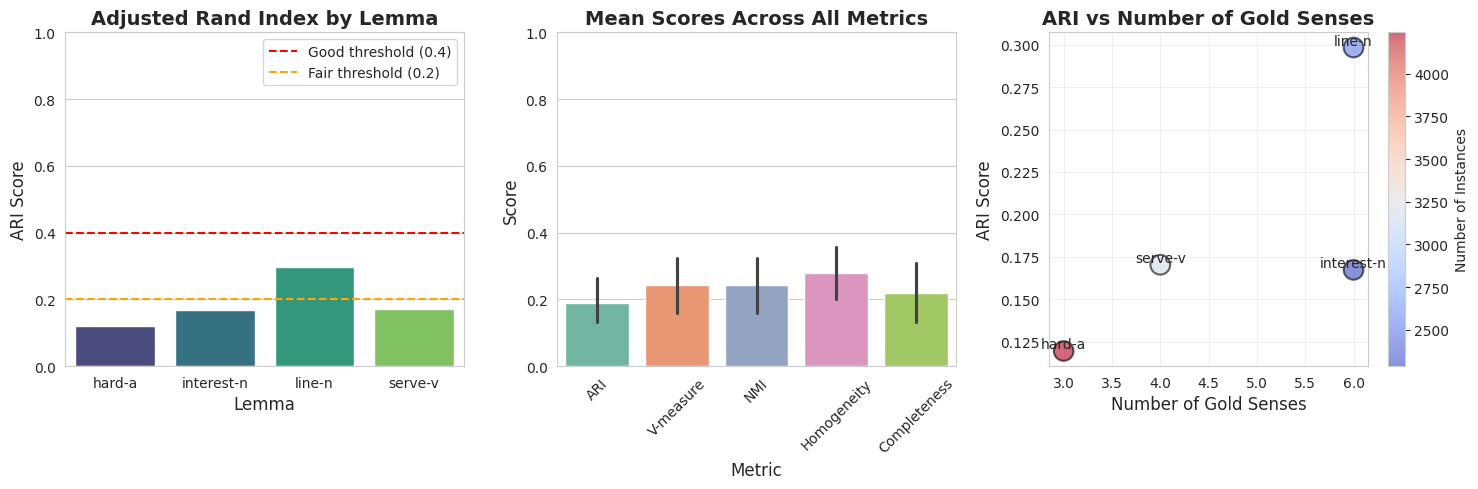

Figure saved to: /home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_validation_results.png


In [10]:
# Set style
sns.set_style("whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: ARI scores by lemma
ax1 = axes[0]
sns.barplot(data=results_df, x='lemma', y='ARI', ax=ax1, palette='viridis')
ax1.axhline(y=0.4, color='red', linestyle='--', label='Good threshold (0.4)')
ax1.axhline(y=0.2, color='orange', linestyle='--', label='Fair threshold (0.2)')
ax1.set_title('Adjusted Rand Index by Lemma', fontsize=14, fontweight='bold')
ax1.set_xlabel('Lemma', fontsize=12)
ax1.set_ylabel('ARI Score', fontsize=12)
ax1.legend()
ax1.set_ylim(0, 1)

# Plot 2: All metrics comparison
ax2 = axes[1]
metrics_to_plot = ['ARI', 'V-measure', 'NMI', 'Homogeneity', 'Completeness']
results_melted = results_df.melt(id_vars=['lemma'], value_vars=metrics_to_plot, 
                                  var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Metric', y='Score', ax=ax2, palette='Set2')
ax2.set_title('Mean Scores Across All Metrics', fontsize=14, fontweight='bold')
ax2.set_xlabel('Metric', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Number of senses vs ARI
ax3 = axes[2]
ax3.scatter(results_df['n_gold_senses'], results_df['ARI'], s=200, alpha=0.6, c=results_df['n_instances'], 
            cmap='coolwarm', edgecolors='black', linewidth=1.5)
for idx, row in results_df.iterrows():
    ax3.annotate(row['lemma'], (row['n_gold_senses'], row['ARI']), 
                 fontsize=10, ha='center', va='bottom')
ax3.set_title('ARI vs Number of Gold Senses', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Gold Senses', fontsize=12)
ax3.set_ylabel('ARI Score', fontsize=12)
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(ax3.collections[0], ax=ax3)
cbar.set_label('Number of Instances', fontsize=10)

plt.tight_layout()
plt.savefig('/home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_validation_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to: /home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_validation_results.png")

## 5. Save Results

In [12]:
# Save results to CSV
results_df.to_csv('/home/gsc685/acl_metapragmatics/pedersen_validation_binder/pedersen_validation_results.csv', index=False)
print("Results saved to: /home/gsc685/acl_metapragmatics/pedersen_validation_binder/pedersen_validation_results.csv")

# Create a summary interpretation
print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)

mean_ari = results_df['ARI'].mean()

if mean_ari >= 0.4:
    interpretation = "STRONG: Feature-based clustering shows MODERATE to SUBSTANTIAL agreement with gold senses."
    recommendation = "Method is validated. Proceed with full analysis."
elif mean_ari >= 0.2:
    interpretation = "FAIR: Feature-based clustering shows FAIR agreement with gold senses."
    recommendation = "Method shows promise but needs refinement. Consider normalization strategies."
else:
    interpretation = "WEAK: Feature-based clustering shows POOR agreement with gold senses."
    recommendation = "Method may not be suitable for this task. Reconsider approach."

print(f"\nOverall Assessment: {interpretation}")
print(f"Recommendation: {recommendation}")

print("\nPer-lemma assessment:")
for _, row in results_df.iterrows():
    if row['ARI'] >= 0.4:
        quality = "GOOD"
    elif row['ARI'] >= 0.2:
        quality = "FAIR"
    else:
        quality = "POOR"
    print(f"  {row['lemma']:12s}: ARI={row['ARI']:.3f} ({quality}) - {row['n_gold_senses']} senses, {row['n_instances']} instances")

Results saved to: /home/gsc685/acl_metapragmatics/pedersen_validation_binder/pedersen_validation_results.csv

INTERPRETATION

Overall Assessment: WEAK: Feature-based clustering shows POOR agreement with gold senses.
Recommendation: Method may not be suitable for this task. Reconsider approach.

Per-lemma assessment:
  hard-a      : ARI=0.120 (POOR) - 3 senses, 4243 instances
  interest-n  : ARI=0.167 (POOR) - 6 senses, 2287 instances
  line-n      : ARI=0.298 (FAIR) - 6 senses, 2530 instances
  serve-v     : ARI=0.170 (POOR) - 4 senses, 3180 instances


## 6. Optimal K Search

The analysis above used k=n_senses. However, due to imbalanced cluster sizes, the optimal k may differ. Let's search for the k that maximizes ARI and V-measure for each lemma.

In [13]:
# Dictionary to store optimal k results
optimal_k_results = []
k_search_details = []  # Store all k attempts for visualization

# Lemmas to validate
lemmas = ['hard-a', 'interest-n', 'line-n', 'serve-v']

for lemma in lemmas:
    print(f"\n{'='*70}")
    print(f"Processing: {lemma}")
    print(f"{'='*70}")
    
    # 1. Load features for this lemma
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_binder_layer7.csv'
    features_df = pd.read_csv(features_path)
    
    # 2. Get subset of pedersen_df for this lemma
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    
    # 3. Get number of senses for this lemma
    n_senses = lemma_data['sense'].nunique()
    sense_counts = lemma_data.groupby('sense').size()
    print(f"Number of gold senses: {n_senses}")
    print(f"Sense distribution:\n{sense_counts}")
    
    # 4. Transform features into feature vectors
    print(f"\nTransforming to feature vectors...")
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    
    # Ensure we have matching data
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')
    true_labels = lemma_data_filtered['sense'].values
    
    # 5. SEARCH FOR OPTIMAL K
    print(f"\n{'='*70}")
    print(f"SEARCHING FOR OPTIMAL K (k from {max(2, n_senses-2)} to {n_senses+4})")
    print(f"{'='*70}")
    
    # Define k range to search
    k_min = max(2, n_senses - 2)
    k_max = n_senses + 5
    k_range = range(k_min, k_max)
    
    best_ari = -1
    best_v_measure = -1
    best_k_ari = None
    best_k_vmeasure = None
    best_cluster_labels = None
    best_metrics = None
    
    # Try each k value
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(feature_matrix_filtered)
        
        # Calculate metrics
        ari = adjusted_rand_score(true_labels, cluster_labels)
        v_measure = v_measure_score(true_labels, cluster_labels)
        nmi = normalized_mutual_info_score(true_labels, cluster_labels)
        homogeneity = homogeneity_score(true_labels, cluster_labels)
        completeness = completeness_score(true_labels, cluster_labels)
        
        print(f"  k={k:2d}: ARI={ari:.3f}, V-measure={v_measure:.3f}, Homog={homogeneity:.3f}, Compl={completeness:.3f}")
        
        # Store k search results for later visualization
        k_search_details.append({
            'lemma': lemma,
            'k': k,
            'n_gold_senses': n_senses,
            'ARI': ari,
            'V-measure': v_measure,
            'NMI': nmi,
            'Homogeneity': homogeneity,
            'Completeness': completeness
        })
        
        # Track best k for ARI
        if ari > best_ari:
            best_ari = ari
            best_k_ari = k
        
        # Track best k for V-measure (our primary criterion)
        if v_measure > best_v_measure:
            best_v_measure = v_measure
            best_k_vmeasure = k
            best_cluster_labels = cluster_labels
            best_metrics = {
                'ari': ari,
                'v_measure': v_measure,
                'nmi': nmi,
                'homogeneity': homogeneity,
                'completeness': completeness
            }
    
    # 6. Report best results
    print(f"\n{'='*70}")
    print(f"BEST RESULTS FOR {lemma}:")
    print(f"{'='*70}")
    print(f"Best k by ARI:       k={best_k_ari} (ARI={best_ari:.3f})")
    print(f"Best k by V-measure: k={best_k_vmeasure} (V-measure={best_v_measure:.3f})")
    
    # Use V-measure for final selection (balances homogeneity & completeness)
    optimal_k = best_k_vmeasure
    print(f"\n>>> OPTIMAL k={optimal_k} (maximizes V-measure)")
    print(f"    Gold senses: {n_senses}, Optimal clusters: {optimal_k} (difference: {optimal_k - n_senses:+d})")
    
    print(f"\nFinal Validation Metrics (k={optimal_k}):")
    print(f"  Adjusted Rand Index:  {best_metrics['ari']:.3f}")
    print(f"  V-measure:            {best_metrics['v_measure']:.3f}")
    print(f"  NMI:                  {best_metrics['nmi']:.3f}")
    print(f"  Homogeneity:          {best_metrics['homogeneity']:.3f}")
    print(f"  Completeness:         {best_metrics['completeness']:.3f}")
    
    # Store results
    optimal_k_results.append({
        'lemma': lemma,
        'n_instances': len(lemma_data_filtered),
        'n_gold_senses': n_senses,
        'optimal_k': optimal_k,
        'k_difference': optimal_k - n_senses,
        'best_k_ari': best_k_ari,
        'n_features': feature_matrix_filtered.shape[1],
        'ARI': best_metrics['ari'],
        'V-measure': best_metrics['v_measure'],
        'NMI': best_metrics['nmi'],
        'Homogeneity': best_metrics['homogeneity'],
        'Completeness': best_metrics['completeness']
    })
    
    # Create confusion matrix
    confusion = pd.crosstab(
        pd.Series(true_labels, name='Gold Sense'),
        pd.Series(best_cluster_labels, name=f'Predicted Cluster'),
        margins=True
    )
    print(f"\nConfusion Matrix (k={optimal_k}):")
    print(confusion)

print(f"\n{'='*70}")
print("OPTIMAL K SEARCH COMPLETE")
print(f"{'='*70}")


Processing: hard-a
Number of gold senses: 3
Sense distribution:
sense
HARD1    3455
HARD2     502
HARD3     376
dtype: int64

Transforming to feature vectors...

SEARCHING FOR OPTIMAL K (k from 2 to 7)
  k= 2: ARI=0.277, V-measure=0.143, Homog=0.138, Compl=0.148
  k= 3: ARI=0.120, V-measure=0.122, Homog=0.161, Compl=0.098
  k= 4: ARI=0.080, V-measure=0.115, Homog=0.176, Compl=0.086
  k= 5: ARI=0.071, V-measure=0.119, Homog=0.203, Compl=0.084
  k= 6: ARI=0.078, V-measure=0.145, Homog=0.263, Compl=0.101
  k= 7: ARI=0.072, V-measure=0.149, Homog=0.289, Compl=0.100

BEST RESULTS FOR hard-a:
Best k by ARI:       k=2 (ARI=0.277)
Best k by V-measure: k=7 (V-measure=0.149)

>>> OPTIMAL k=7 (maximizes V-measure)
    Gold senses: 3, Optimal clusters: 7 (difference: +4)

Final Validation Metrics (k=7):
  Adjusted Rand Index:  0.072
  V-measure:            0.149
  NMI:                  0.149
  Homogeneity:          0.289
  Completeness:         0.100

Confusion Matrix (k=7):
Predicted Cluster    

### 6.1 Optimal K Results Summary

In [15]:
# Create summary results dataframe
optimal_results_df = pd.DataFrame(optimal_k_results)

print("="*80)
print("OPTIMAL K VALIDATION RESULTS")
print("="*80)
print(optimal_results_df.to_string(index=False))

print("\n" + "="*80)
print("COMPARISON: k=n_senses vs OPTIMAL k")
print("="*80)

# Compare with original results
comparison_df = pd.DataFrame({
    'lemma': optimal_results_df['lemma'],
    'n_gold_senses': optimal_results_df['n_gold_senses'],
    'optimal_k': optimal_results_df['optimal_k'],
    'k_diff': optimal_results_df['k_difference'],
    'ARI_optimal': optimal_results_df['ARI'],
    'ARI_baseline': results_df['ARI'],
    'ARI_improvement': optimal_results_df['ARI'] - results_df['ARI'],
    'V-measure_optimal': optimal_results_df['V-measure'],
    'V-measure_baseline': results_df['V-measure'],
    'V_improvement': optimal_results_df['V-measure'] - results_df['V-measure']
})

print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS (OPTIMAL K)")
print("="*80)
print(f"Mean ARI:         {optimal_results_df['ARI'].mean():.3f} ± {optimal_results_df['ARI'].std():.3f}")
print(f"Mean V-measure:   {optimal_results_df['V-measure'].mean():.3f} ± {optimal_results_df['V-measure'].std():.3f}")
print(f"Mean NMI:         {optimal_results_df['NMI'].mean():.3f} ± {optimal_results_df['NMI'].std():.3f}")
print(f"Mean Homogeneity: {optimal_results_df['Homogeneity'].mean():.3f} ± {optimal_results_df['Homogeneity'].std():.3f}")
print(f"Mean Completeness:{optimal_results_df['Completeness'].mean():.3f} ± {optimal_results_df['Completeness'].std():.3f}")

print(f"\nLemmas with ARI > 0.4: {(optimal_results_df['ARI'] > 0.4).sum()} / {len(optimal_results_df)}")
print(f"Lemmas with ARI > 0.3: {(optimal_results_df['ARI'] > 0.3).sum()} / {len(optimal_results_df)}")
print(f"Lemmas with ARI > 0.2: {(optimal_results_df['ARI'] > 0.2).sum()} / {len(optimal_results_df)}")

print(f"\nAverage ARI improvement from k search: {comparison_df['ARI_improvement'].mean():.3f}")
print(f"Average V-measure improvement:         {comparison_df['V_improvement'].mean():.3f}")

# Display
optimal_results_df

OPTIMAL K VALIDATION RESULTS
     lemma  n_instances  n_gold_senses  optimal_k  k_difference  best_k_ari  n_features      ARI  V-measure      NMI  Homogeneity  Completeness
    hard-a         4243              3          7             4           2          65 0.071733   0.149163 0.149163     0.289225      0.100496
interest-n         2287              6          9             3           4          65 0.158486   0.288725 0.288725     0.391132      0.228817
    line-n         2530              6          7             1           6          65 0.252476   0.360338 0.360338     0.406440      0.323629
   serve-v         3180              4          2            -2           2          65 0.261993   0.282939 0.282939     0.224520      0.382451

COMPARISON: k=n_senses vs OPTIMAL k
     lemma  n_gold_senses  optimal_k  k_diff  ARI_optimal  ARI_baseline  ARI_improvement  V-measure_optimal  V-measure_baseline  V_improvement
    hard-a              3          7       4     0.071733      0.119651

,lemma,n_instances,n_gold_senses,optimal_k,k_difference,best_k_ari,n_features,ARI,V-measure,NMI,Homogeneity,Completeness
0,hard-a,4243,3,7,4,2,65,0.071733,0.149163,0.149163,0.289225,0.100496
1,interest-n,2287,6,9,3,4,65,0.158486,0.288725,0.288725,0.391132,0.228817
2,line-n,2530,6,7,1,6,65,0.252476,0.360338,0.360338,0.406440,0.323629
3,serve-v,3180,4,2,-2,2,65,0.261993,0.282939,0.282939,0.224520,0.382451


### 6.2 Visualize K Search Results

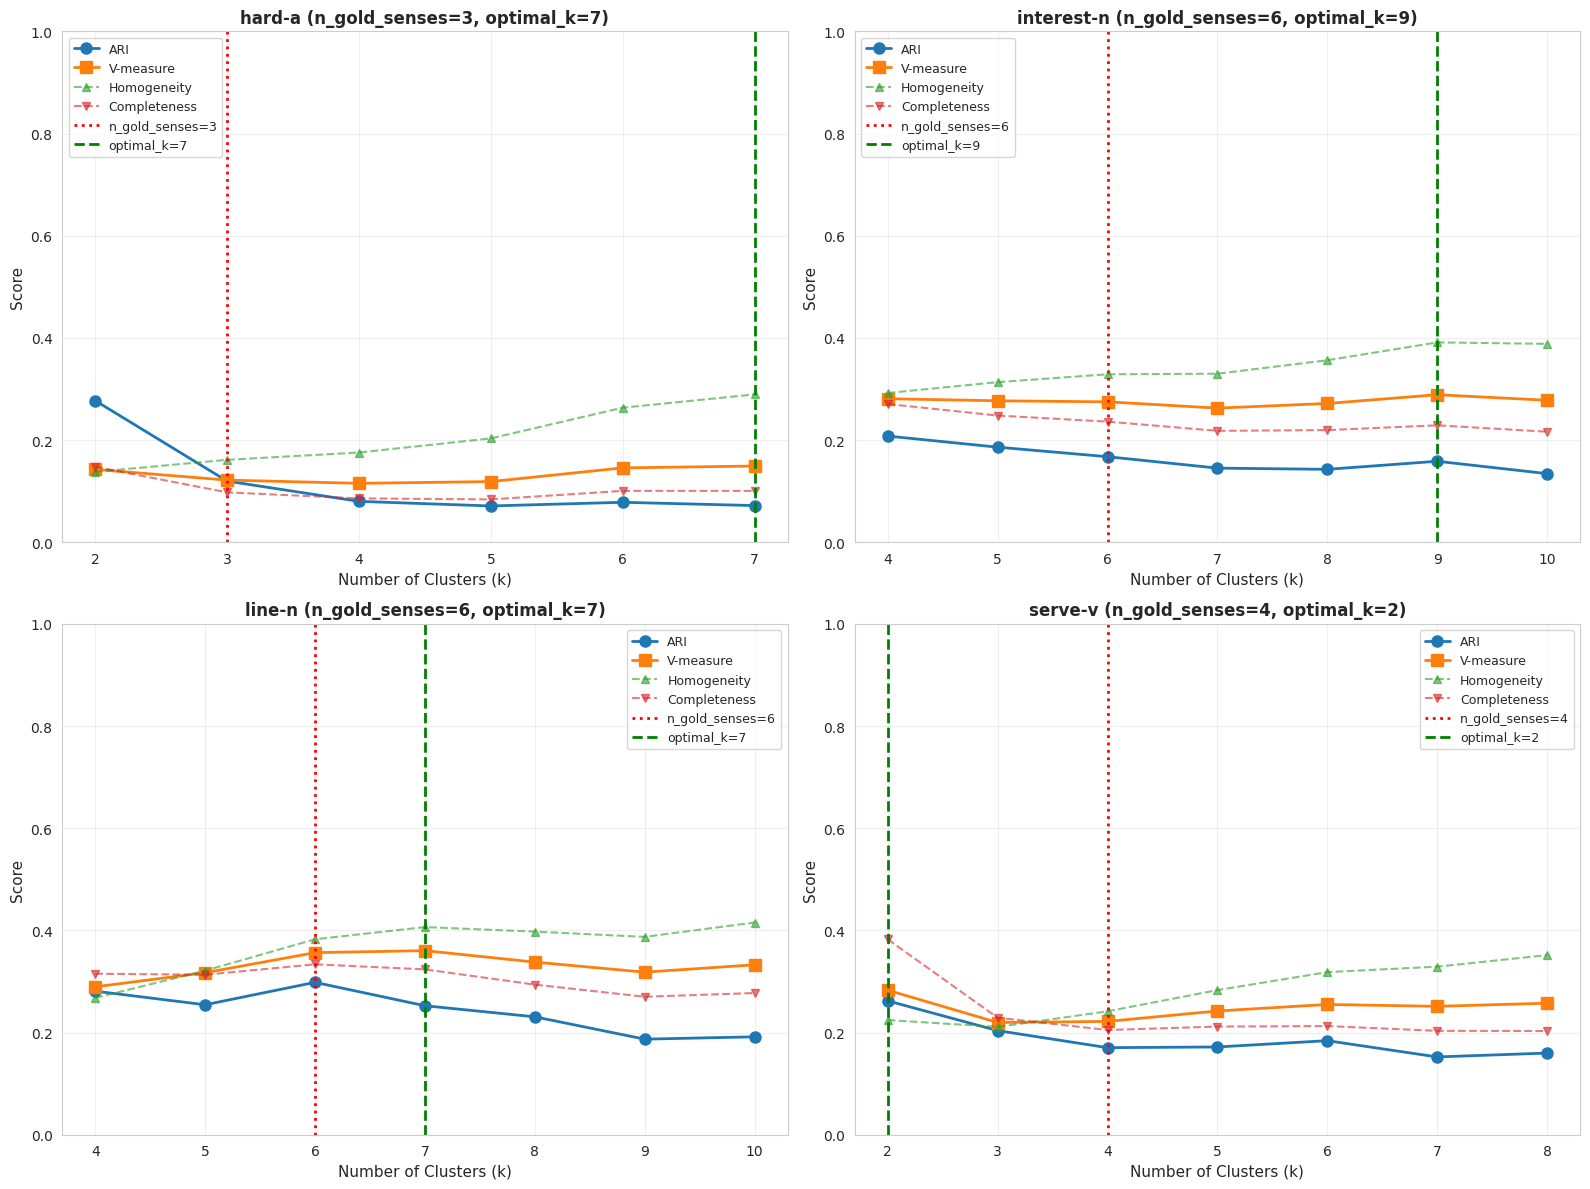

Figure saved to: /home/gsc685/acl_metapragmatics/pedersen_k_search_results.png


In [16]:
# Create dataframe from k search details
k_search_df = pd.DataFrame(k_search_details)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, lemma in enumerate(lemmas):
    ax = axes[idx]
    
    # Filter data for this lemma
    lemma_search = k_search_df[k_search_df['lemma'] == lemma]
    n_gold = lemma_search['n_gold_senses'].iloc[0]
    
    # Get optimal k
    optimal_k_row = optimal_results_df[optimal_results_df['lemma'] == lemma].iloc[0]
    optimal_k = optimal_k_row['optimal_k']
    
    # Plot ARI and V-measure
    ax.plot(lemma_search['k'], lemma_search['ARI'], 'o-', label='ARI', linewidth=2, markersize=8)
    ax.plot(lemma_search['k'], lemma_search['V-measure'], 's-', label='V-measure', linewidth=2, markersize=8)
    ax.plot(lemma_search['k'], lemma_search['Homogeneity'], '^--', label='Homogeneity', alpha=0.6)
    ax.plot(lemma_search['k'], lemma_search['Completeness'], 'v--', label='Completeness', alpha=0.6)
    
    # Mark n_senses and optimal_k
    ax.axvline(x=n_gold, color='red', linestyle=':', linewidth=2, label=f'n_gold_senses={n_gold}')
    ax.axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'optimal_k={optimal_k}')
    
    ax.set_title(f'{lemma} (n_gold_senses={n_gold}, optimal_k={optimal_k})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('/home/gsc685/acl_metapragmatics/pedersen_k_search_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to: /home/gsc685/acl_metapragmatics/pedersen_k_search_results.png")

## 7. Hierarchical Clustering Analysis

Word senses are naturally hierarchical - some senses are more closely related than others. Hierarchical clustering can:
- Handle imbalanced cluster sizes better than k-means
- Reveal sub-sense structure within broad senses
- Show which senses are semantically closer
- Provide interpretable dendrograms of sense relationships

We'll compare multiple linkage methods and visualize the sense hierarchies.

### 7.1 Compare Linkage Methods

In [23]:
from sklearn.cluster import AgglomerativeClustering

# Store hierarchical clustering results
hierarchical_results = []

# Linkage methods to compare
linkage_methods = ['ward', 'average', 'complete', 'single']

for lemma in lemmas:
    print(f"\n{'='*70}")
    print(f"Hierarchical Clustering: {lemma}")
    print(f"{'='*70}")
    
    # Load and prepare data (same as before)
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_binder_layer7.csv'
    features_df = pd.read_csv(features_path)
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    
    n_senses = lemma_data['sense'].nunique()
    print(f"Gold senses: {n_senses}")
    
    # Transform features
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')
    true_labels = lemma_data_filtered['sense'].values
    
    print(f"\nComparing linkage methods (k={n_senses}):")
    print(f"{'Method':<15} {'ARI':>6} {'V-measure':>10} {'Homog':>6} {'Compl':>6}")
    print("-" * 50)
    
    best_method = None
    best_ari = -1
    
    for method in linkage_methods:
        # Fit agglomerative clustering
        agg = AgglomerativeClustering(n_clusters=n_senses, linkage=method)
        cluster_labels = agg.fit_predict(feature_matrix_filtered)
        
        # Calculate metrics
        ari = adjusted_rand_score(true_labels, cluster_labels)
        v_measure = v_measure_score(true_labels, cluster_labels)
        homogeneity = homogeneity_score(true_labels, cluster_labels)
        completeness = completeness_score(true_labels, cluster_labels)
        nmi = normalized_mutual_info_score(true_labels, cluster_labels)
        
        print(f"{method:<15} {ari:6.3f} {v_measure:10.3f} {homogeneity:6.3f} {completeness:6.3f}")
        
        # Track best method
        if ari > best_ari:
            best_ari = ari
            best_method = method
        
        # Store results
        hierarchical_results.append({
            'lemma': lemma,
            'method': method,
            'n_gold_senses': n_senses,
            'n_clusters': n_senses,
            'ARI': ari,
            'V-measure': v_measure,
            'NMI': nmi,
            'Homogeneity': homogeneity,
            'Completeness': completeness
        })
    
    print(f"\nBest linkage method for {lemma}: {best_method} (ARI={best_ari:.3f})")

print(f"\n{'='*70}")
print("LINKAGE METHOD COMPARISON COMPLETE")
print(f"{'='*70}")


Hierarchical Clustering: hard-a
Gold senses: 3

Comparing linkage methods (k=3):
Method             ARI  V-measure  Homog  Compl
--------------------------------------------------
ward             0.140      0.135  0.179  0.109
average          0.060      0.053  0.029  0.321
complete         0.334      0.173  0.138  0.230
single           0.003      0.003  0.002  0.247

Best linkage method for hard-a: complete (ARI=0.334)

Hierarchical Clustering: interest-n
Gold senses: 6

Comparing linkage methods (k=6):
Method             ARI  V-measure  Homog  Compl
--------------------------------------------------
ward             0.211      0.277  0.328  0.241
average          0.322      0.266  0.193  0.426
complete         0.149      0.248  0.271  0.228
single           0.001      0.006  0.003  0.196

Best linkage method for interest-n: average (ARI=0.322)

Hierarchical Clustering: line-n
Gold senses: 6

Comparing linkage methods (k=6):
Method             ARI  V-measure  Homog  Compl
---------

### 7.2 Hierarchical Results Summary

In [24]:
# Create summary dataframe
hierarchical_df = pd.DataFrame(hierarchical_results)

print("="*80)
print("HIERARCHICAL CLUSTERING RESULTS (by linkage method)")
print("="*80)

# Pivot to show all methods side by side
pivot_ari = hierarchical_df.pivot(index='lemma', columns='method', values='ARI')
pivot_vmeasure = hierarchical_df.pivot(index='lemma', columns='method', values='V-measure')

print("\nAdjusted Rand Index by Linkage Method:")
print(pivot_ari.to_string())

print("\n\nV-measure by Linkage Method:")
print(pivot_vmeasure.to_string())

# Find best method per lemma
best_per_lemma = hierarchical_df.loc[hierarchical_df.groupby('lemma')['ARI'].idxmax()]
print("\n\nBest Linkage Method per Lemma (by ARI):")
print(best_per_lemma[['lemma', 'method', 'ARI', 'V-measure']].to_string(index=False))

# Compare to k-means baseline (k=n_senses)
print("\n" + "="*80)
print("COMPARISON: K-means vs Best Hierarchical Method")
print("="*80)

comparison_hier = pd.DataFrame({
    'lemma': best_per_lemma['lemma'].values,
    'best_method': best_per_lemma['method'].values,
    'hierarchical_ARI': best_per_lemma['ARI'].values,
    'kmeans_ARI': results_df['ARI'].values,
    'ARI_improvement': best_per_lemma['ARI'].values - results_df['ARI'].values,
    'hierarchical_V': best_per_lemma['V-measure'].values,
    'kmeans_V': results_df['V-measure'].values,
    'V_improvement': best_per_lemma['V-measure'].values - results_df['V-measure'].values
})

print(comparison_hier.to_string(index=False))

print(f"\nAverage ARI improvement (Hierarchical vs K-means): {comparison_hier['ARI_improvement'].mean():.3f}")
print(f"Average V-measure improvement:                      {comparison_hier['V_improvement'].mean():.3f}")

print(f"\nLemmas where hierarchical > k-means (ARI): {(comparison_hier['ARI_improvement'] > 0).sum()} / {len(comparison_hier)}")
print(f"Lemmas where hierarchical > k-means (V-m): {(comparison_hier['V_improvement'] > 0).sum()} / {len(comparison_hier)}")

HIERARCHICAL CLUSTERING RESULTS (by linkage method)

Adjusted Rand Index by Linkage Method:
method       average  complete    single      ward
lemma                                             
hard-a      0.060163  0.333784  0.003106  0.140384
interest-n  0.322272  0.148552  0.001018  0.211330
line-n      0.006941  0.069541  0.001361  0.271187
serve-v     0.008442  0.039192  0.000147  0.197668


V-measure by Linkage Method:
method       average  complete    single      ward
lemma                                             
hard-a      0.053263  0.172584  0.003398  0.135358
interest-n  0.265728  0.247778  0.005810  0.277479
line-n      0.013055  0.205878  0.005313  0.332627
serve-v     0.022361  0.130307  0.001855  0.220776


Best Linkage Method per Lemma (by ARI):
     lemma   method      ARI  V-measure
    hard-a complete 0.333784   0.172584
interest-n  average 0.322272   0.265728
    line-n     ward 0.271187   0.332627
   serve-v     ward 0.197668   0.220776

COMPARISON: K-means vs

### 7.3 Visualize Dendrograms

Dendrograms show the hierarchical structure of word senses. Points that merge early are more similar; points that merge late are more distinct.

Creating dendrogram for hard-a...
Creating dendrogram for interest-n...
Creating dendrogram for line-n...
Creating dendrogram for serve-v...


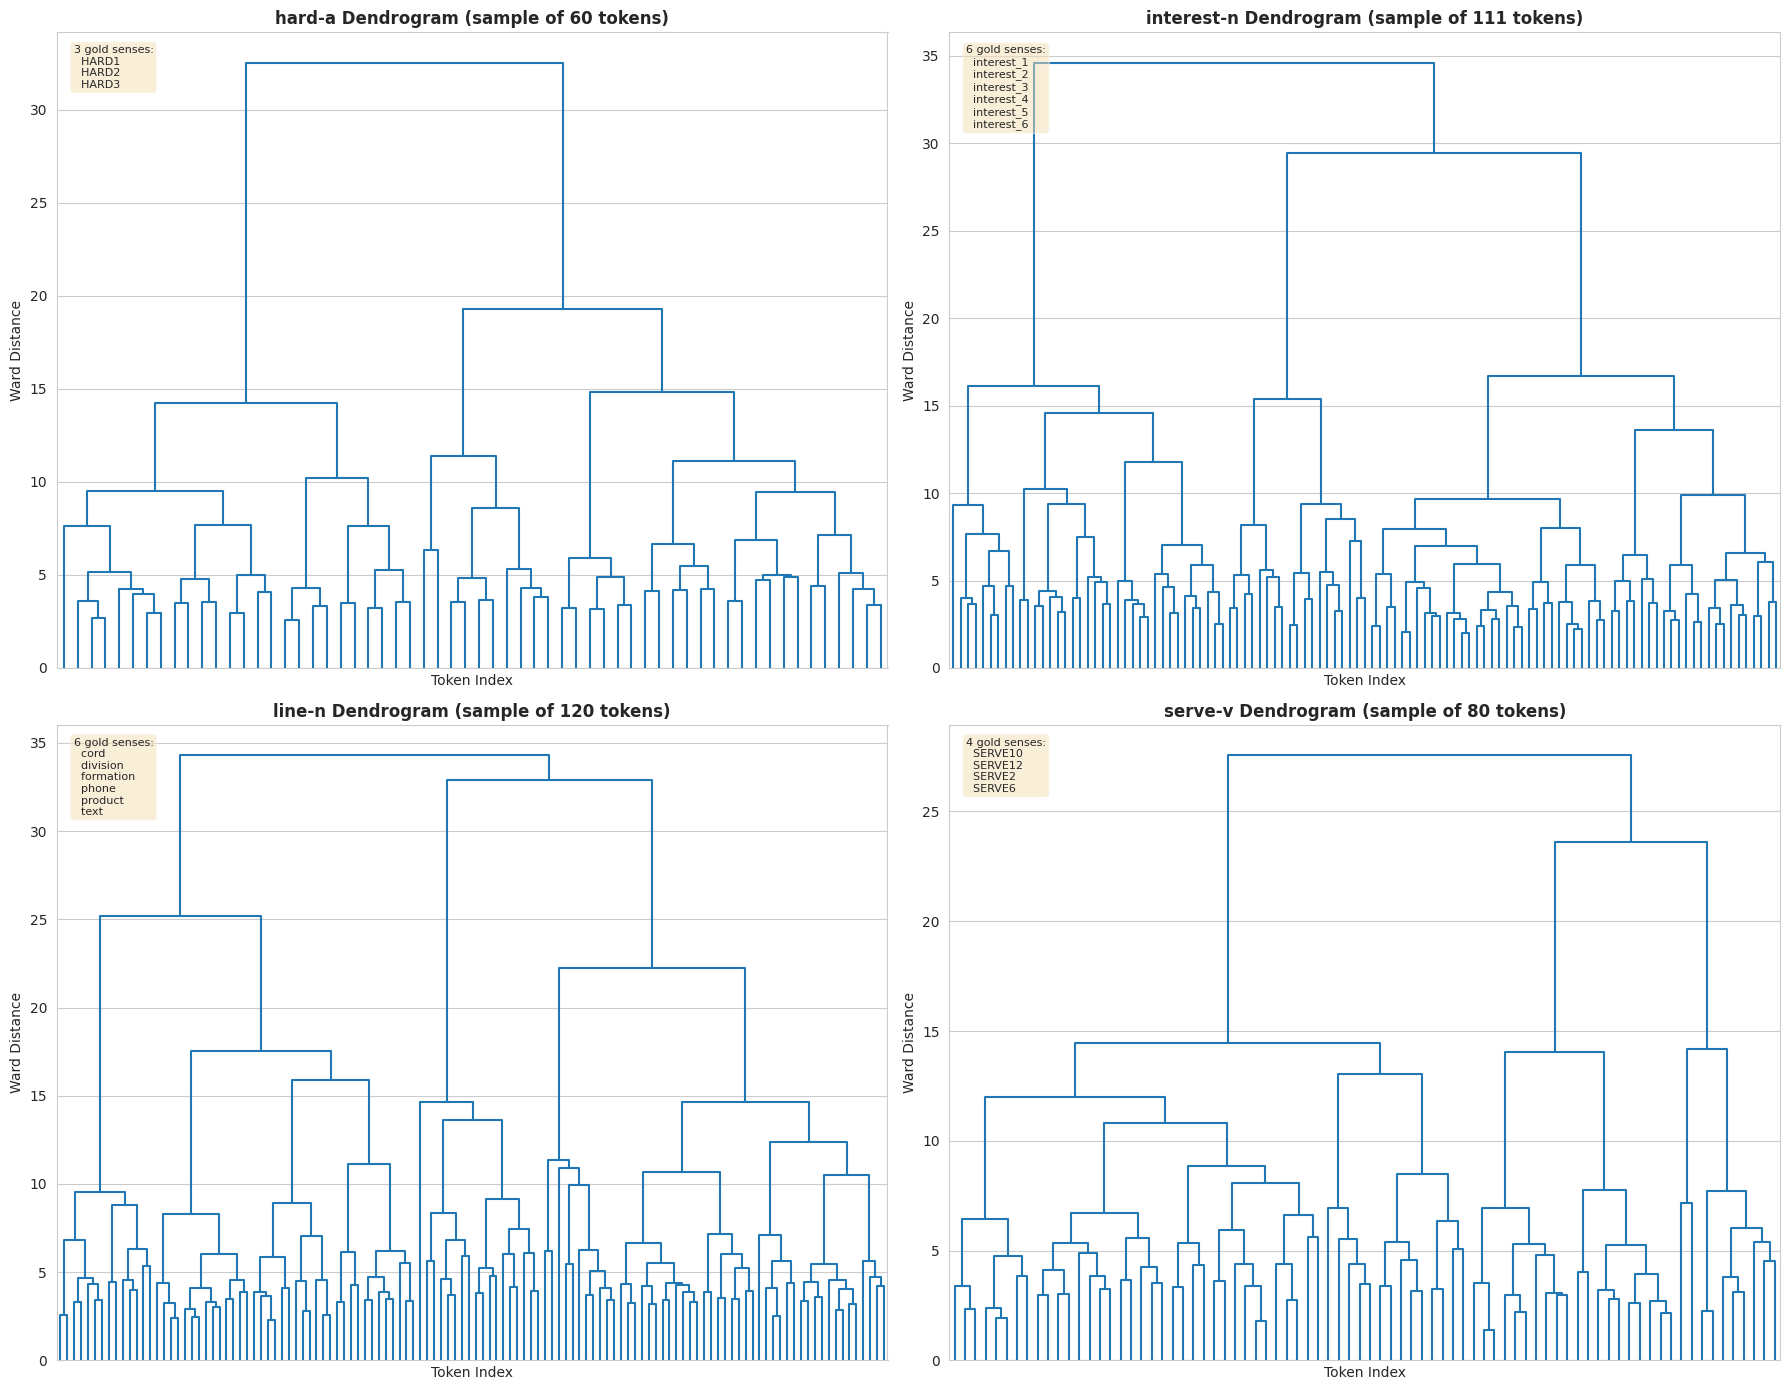


Figure saved to: /home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_dendrograms.png


In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Create dendrograms for each lemma
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, lemma in enumerate(lemmas):
    ax = axes[idx]
    
    print(f"Creating dendrogram for {lemma}...")
    
    # Load and prepare data
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_binder_layer7.csv'
    features_df = pd.read_csv(features_path)
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    
    # Transform features
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')
    true_labels = lemma_data_filtered['sense'].values
    
    # Compute linkage (using Ward method as it tends to work best)
    Z = linkage(feature_matrix_filtered, method='complete')
    
    # Create color map for gold senses
    unique_senses = sorted(set(true_labels))
    sense_to_color = {sense: f'C{i}' for i, sense in enumerate(unique_senses)}
    label_colors = [sense_to_color[sense] for sense in true_labels]
    
    # Sample for visualization if too many points (dendrograms get crowded)
    if len(true_labels) > 100:
        # Sample proportionally from each sense
        sample_indices = []
        for sense in unique_senses:
            sense_indices = np.where(true_labels == sense)[0]
            n_sample = min(20, len(sense_indices))  # Max 20 per sense
            sample_indices.extend(np.random.choice(sense_indices, n_sample, replace=False))
        
        sample_indices = sorted(sample_indices)
        feature_matrix_sample = feature_matrix_filtered.iloc[sample_indices]
        true_labels_sample = true_labels[sample_indices]
        
        # Recompute linkage on sample
        Z_sample = linkage(feature_matrix_sample, method='ward')
        
        dendrogram(Z_sample, ax=ax, no_labels=True, color_threshold=0)
        ax.set_title(f'{lemma} Dendrogram (sample of {len(sample_indices)} tokens)', 
                     fontsize=12, fontweight='bold')
    else:
        dendrogram(Z, ax=ax, no_labels=True, color_threshold=0)
        ax.set_title(f'{lemma} Dendrogram ({len(true_labels)} tokens)', 
                     fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Token Index', fontsize=10)
    ax.set_ylabel('Ward Distance', fontsize=10)
    
    # Add legend for senses
    n_senses = len(unique_senses)
    ax.text(0.02, 0.98, f'{n_senses} gold senses:\n' + '\n'.join([f'  {s}' for s in unique_senses]),
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/home/gsc685/acl_metapragmatics/pedersen_validation_binder/pedersen_dendrograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved to: /home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_dendrograms.png")

### 7.4 Optimal K Search for Hierarchical Clustering

Just as with k-means, we can search for the optimal number of clusters with hierarchical methods.

In [22]:
# Search for optimal k using best hierarchical method per lemma
hierarchical_k_search = []
hierarchical_optimal_results = []

for lemma in lemmas:
    print(f"\n{'='*70}")
    print(f"Hierarchical K-Search: {lemma}")
    print(f"{'='*70}")
    
    # Load data
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_binder_layer7.csv'
    features_df = pd.read_csv(features_path)
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    
    n_senses = lemma_data['sense'].nunique()
    
    # Transform features
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')
    true_labels = lemma_data_filtered['sense'].values
    
    # Determine best linkage method for this lemma from previous analysis
    lemma_hier_results = hierarchical_df[hierarchical_df['lemma'] == lemma]
    best_method = lemma_hier_results.loc[lemma_hier_results['ARI'].idxmax(), 'method']
    print(f"Using best linkage method: {best_method}")
    
    # K search range
    k_min = max(2, n_senses - 2)
    k_max = n_senses + 5
    k_range = range(k_min, k_max)
    
    print(f"Searching k from {k_min} to {k_max-1}...")
    
    best_ari = -1
    best_v_measure = -1
    best_k = None
    best_metrics = None
    best_labels = None
    
    for k in k_range:
        agg = AgglomerativeClustering(n_clusters=k, linkage=best_method)
        cluster_labels = agg.fit_predict(feature_matrix_filtered)
        
        ari = adjusted_rand_score(true_labels, cluster_labels)
        v_measure = v_measure_score(true_labels, cluster_labels)
        nmi = normalized_mutual_info_score(true_labels, cluster_labels)
        homogeneity = homogeneity_score(true_labels, cluster_labels)
        completeness = completeness_score(true_labels, cluster_labels)
        
        print(f"  k={k:2d}: ARI={ari:.3f}, V-measure={v_measure:.3f}")
        
        # Store k search details
        hierarchical_k_search.append({
            'lemma': lemma,
            'method': best_method,
            'k': k,
            'n_gold_senses': n_senses,
            'ARI': ari,
            'V-measure': v_measure,
            'NMI': nmi,
            'Homogeneity': homogeneity,
            'Completeness': completeness
        })
        
        # Track best k by V-measure
        if v_measure > best_v_measure:
            best_v_measure = v_measure
            best_ari = ari
            best_k = k
            best_labels = cluster_labels
            best_metrics = {
                'ari': ari,
                'v_measure': v_measure,
                'nmi': nmi,
                'homogeneity': homogeneity,
                'completeness': completeness
            }
    
    print(f"\n>>> OPTIMAL k={best_k} for {lemma} using {best_method}")
    print(f"    ARI={best_metrics['ari']:.3f}, V-measure={best_metrics['v_measure']:.3f}")
    
    # Store optimal results
    hierarchical_optimal_results.append({
        'lemma': lemma,
        'method': best_method,
        'n_gold_senses': n_senses,
        'optimal_k': best_k,
        'k_difference': best_k - n_senses,
        'ARI': best_metrics['ari'],
        'V-measure': best_metrics['v_measure'],
        'NMI': best_metrics['nmi'],
        'Homogeneity': best_metrics['homogeneity'],
        'Completeness': best_metrics['completeness']
    })
    
    # Show confusion matrix at optimal k
    confusion = pd.crosstab(
        pd.Series(true_labels, name='Gold Sense'),
        pd.Series(best_labels, name='Predicted Cluster'),
        margins=True
    )
    print(f"\nConfusion Matrix (k={best_k}):")
    print(confusion)

print(f"\n{'='*70}")
print("HIERARCHICAL K-SEARCH COMPLETE")
print(f"{'='*70}")


Hierarchical K-Search: hard-a
Using best linkage method: complete
Searching k from 2 to 7...
  k= 2: ARI=0.231, V-measure=0.114
  k= 3: ARI=0.334, V-measure=0.173
  k= 4: ARI=0.149, V-measure=0.125
  k= 5: ARI=0.151, V-measure=0.136
  k= 6: ARI=0.138, V-measure=0.127
  k= 7: ARI=0.138, V-measure=0.127

>>> OPTIMAL k=3 for hard-a using complete
    ARI=0.334, V-measure=0.173

Confusion Matrix (k=3):
Predicted Cluster     0    1    2   All
Gold Sense                             
HARD1              3281   64   49  3394
HARD2               307   69  108   484
HARD3               246  118    1   365
All                3834  251  158  4243

Hierarchical K-Search: interest-n
Using best linkage method: ward
Searching k from 4 to 10...
  k= 4: ARI=0.266, V-measure=0.281
  k= 5: ARI=0.201, V-measure=0.266
  k= 6: ARI=0.211, V-measure=0.277
  k= 7: ARI=0.205, V-measure=0.275
  k= 8: ARI=0.177, V-measure=0.266
  k= 9: ARI=0.155, V-measure=0.267
  k=10: ARI=0.164, V-measure=0.267

>>> OPTIMAL k=4 

### 7.5 Final Comparison: K-means vs Hierarchical (Both with Optimal K)

In [26]:
# Create comprehensive comparison dataframe
hierarchical_optimal_df = pd.DataFrame(hierarchical_optimal_results)

final_comparison = pd.DataFrame({
    'lemma': optimal_results_df['lemma'],
    'n_gold_senses': optimal_results_df['n_gold_senses'],
    
    # K-means results
    'kmeans_optimal_k': optimal_results_df['optimal_k'],
    'kmeans_ARI': optimal_results_df['ARI'],
    'kmeans_V': optimal_results_df['V-measure'],
    
    # Hierarchical results
    'hier_method': hierarchical_optimal_df['method'],
    'hier_optimal_k': hierarchical_optimal_df['optimal_k'],
    'hier_ARI': hierarchical_optimal_df['ARI'],
    'hier_V': hierarchical_optimal_df['V-measure'],
    
    # Improvements
    'ARI_diff': hierarchical_optimal_df['ARI'].values - optimal_results_df['ARI'].values,
    'V_diff': hierarchical_optimal_df['V-measure'].values - optimal_results_df['V-measure'].values
})

print("="*90)
print("FINAL COMPARISON: K-MEANS VS HIERARCHICAL (both with optimal k)")
print("="*90)
print(final_comparison.to_string(index=False))

print("\n" + "="*90)
print("SUMMARY")
print("="*90)
print(f"\nMean ARI (K-means optimal k):     {final_comparison['kmeans_ARI'].mean():.3f}")
print(f"Mean ARI (Hierarchical optimal k): {final_comparison['hier_ARI'].mean():.3f}")
print(f"Average ARI improvement:           {final_comparison['ARI_diff'].mean():.3f}")

print(f"\nMean V-measure (K-means):          {final_comparison['kmeans_V'].mean():.3f}")
print(f"Mean V-measure (Hierarchical):     {final_comparison['hier_V'].mean():.3f}")
print(f"Average V-measure improvement:     {final_comparison['V_diff'].mean():.3f}")

print(f"\nLemmas where Hierarchical > K-means (ARI): {(final_comparison['ARI_diff'] > 0).sum()} / {len(final_comparison)}")
print(f"Lemmas where Hierarchical > K-means (V-m): {(final_comparison['V_diff'] > 0).sum()} / {len(final_comparison)}")

# Overall best method per lemma
print("\n" + "="*90)
print("RECOMMENDED METHOD PER LEMMA")
print("="*90)
for _, row in final_comparison.iterrows():
    if row['hier_ARI'] > row['kmeans_ARI']:
        best = f"Hierarchical ({row['hier_method']}, k={row['hier_optimal_k']})"
        ari = row['hier_ARI']
    else:
        best = f"K-means (k={row['kmeans_optimal_k']})"
        ari = row['kmeans_ARI']
    
    print(f"{row['lemma']:12s}: {best:40s} ARI={ari:.3f}")

final_comparison

FINAL COMPARISON: K-MEANS VS HIERARCHICAL (both with optimal k)
     lemma  n_gold_senses  kmeans_optimal_k  kmeans_ARI  kmeans_V hier_method  hier_optimal_k  hier_ARI   hier_V  ARI_diff    V_diff
    hard-a              3                 7    0.071733  0.149163    complete               3  0.333784 0.172584  0.262051  0.023421
interest-n              6                 9    0.158486  0.288725        ward               4  0.265875 0.280813  0.107388 -0.007913
    line-n              6                 7    0.252476  0.360338    complete               5  0.176184 0.215007 -0.076292 -0.145331
   serve-v              4                 2    0.261993  0.282939    complete               8  0.105574 0.139734 -0.156419 -0.143205

SUMMARY

Mean ARI (K-means optimal k):     0.186
Mean ARI (Hierarchical optimal k): 0.220
Average ARI improvement:           0.034

Mean V-measure (K-means):          0.270
Mean V-measure (Hierarchical):     0.202
Average V-measure improvement:     -0.068

Lemmas where 

,lemma,n_gold_senses,kmeans_optimal_k,kmeans_ARI,kmeans_V,hier_method,hier_optimal_k,hier_ARI,hier_V,ARI_diff,V_diff
0,hard-a,3,7,0.071733,0.149163,complete,3,0.333784,0.172584,0.262051,0.023421
1,interest-n,6,9,0.158486,0.288725,ward,4,0.265875,0.280813,0.107388,-0.007913
2,line-n,6,7,0.252476,0.360338,complete,5,0.176184,0.215007,-0.076292,-0.145331
3,serve-v,4,2,0.261993,0.282939,complete,8,0.105574,0.139734,-0.156419,-0.143205


## 8. HDBSCAN: Density-Based Hierarchical Clustering

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a powerful alternative that:
- **Automatically determines the number of clusters** (no need to specify k)
- **Handles clusters of varying density and size** (better for imbalanced senses)
- **Identifies noise/outliers** (tokens that don't fit any sense clearly)
- **Builds a hierarchy** based on density rather than distance
- **Works well with high-dimensional data** (like our 3,981 features)

This is particularly useful for word senses because:
- Some senses might be very rare (low density)
- Some tokens might be ambiguous (noise)
- We don't know the "true" number of senses a priori

### 8.1 Run HDBSCAN with Multiple Parameter Settings

In [27]:
!pip install hdbscan

In [28]:
import hdbscan

# Store HDBSCAN results
hdbscan_results = []

# Try different min_cluster_size values
# Smaller values = more clusters, larger values = fewer clusters
min_cluster_sizes = [2, 5, 10, 15, 20, 30]

for lemma in lemmas:
    print(f"\n{'='*70}")
    print(f"HDBSCAN Clustering: {lemma}")
    print(f"{'='*70}")
    
    # Load and prepare data
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_binder_layer7.csv'
    features_df = pd.read_csv(features_path)
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    
    n_senses = lemma_data['sense'].nunique()
    print(f"Gold senses: {n_senses}")
    
    # Transform features
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')
    true_labels = lemma_data_filtered['sense'].values
    
    print(f"\nTrying different min_cluster_size parameters:")
    print(f"{'min_cluster_size':<18} {'n_clusters':>12} {'n_noise':>10} {'ARI':>8} {'V-measure':>10}")
    print("-" * 70)
    
    best_ari = -1
    best_params = None
    best_labels = None
    best_metrics = None
    
    for min_size in min_cluster_sizes:
        # Run HDBSCAN
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_size,
            min_samples=1,  # How conservative to be with cluster membership
            metric='euclidean',
            cluster_selection_method='eom'  # Excess of Mass (good for varying densities)
        )
        cluster_labels = clusterer.fit_predict(feature_matrix_filtered)
        
        # Count clusters and noise points
        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        
        # For metrics, treat noise (-1) as its own cluster
        # This is debatable - could also exclude noise from evaluation
        labels_for_eval = cluster_labels.copy()
        
        # Calculate metrics
        if n_clusters > 0:
            ari = adjusted_rand_score(true_labels, labels_for_eval)
            v_measure = v_measure_score(true_labels, labels_for_eval)
            nmi = normalized_mutual_info_score(true_labels, labels_for_eval)
            homogeneity = homogeneity_score(true_labels, labels_for_eval)
            completeness = completeness_score(true_labels, labels_for_eval)
        else:
            # If HDBSCAN found no clusters, metrics are undefined
            ari = v_measure = nmi = homogeneity = completeness = 0.0
        
        print(f"{min_size:<18} {n_clusters:>12} {n_noise:>10} {ari:>8.3f} {v_measure:>10.3f}")
        
        # Store results
        hdbscan_results.append({
            'lemma': lemma,
            'min_cluster_size': min_size,
            'n_gold_senses': n_senses,
            'n_clusters_found': n_clusters,
            'n_noise_points': n_noise,
            'noise_percentage': (n_noise / len(cluster_labels)) * 100,
            'ARI': ari,
            'V-measure': v_measure,
            'NMI': nmi,
            'Homogeneity': homogeneity,
            'Completeness': completeness
        })
        
        # Track best parameters by ARI
        if ari > best_ari:
            best_ari = ari
            best_params = {'min_cluster_size': min_size}
            best_labels = cluster_labels
            best_metrics = {
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'ari': ari,
                'v_measure': v_measure,
                'nmi': nmi,
                'homogeneity': homogeneity,
                'completeness': completeness
            }
    
    # Report best parameters
    print(f"\n{'='*70}")
    print(f"BEST PARAMETERS FOR {lemma}:")
    print(f"{'='*70}")
    print(f"min_cluster_size: {best_params['min_cluster_size']}")
    print(f"Clusters found:   {best_metrics['n_clusters']} (gold senses: {n_senses})")
    print(f"Noise points:     {best_metrics['n_noise']} ({best_metrics['n_noise']/len(true_labels)*100:.1f}%)")
    print(f"ARI:              {best_metrics['ari']:.3f}")
    print(f"V-measure:        {best_metrics['v_measure']:.3f}")
    
    # Show confusion matrix for best parameters
    if best_metrics['n_clusters'] > 0:
        confusion = pd.crosstab(
            pd.Series(true_labels, name='Gold Sense'),
            pd.Series(best_labels, name='HDBSCAN Cluster'),
            margins=True
        )
        print(f"\nConfusion Matrix (best parameters):")
        print(confusion)

print(f"\n{'='*70}")
print("HDBSCAN ANALYSIS COMPLETE")
print(f"{'='*70}")


HDBSCAN Clustering: hard-a
Gold senses: 3

Trying different min_cluster_size parameters:
min_cluster_size     n_clusters    n_noise      ARI  V-measure
----------------------------------------------------------------------


/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


2                           806       2098   -0.029      0.102


/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


5                             2         59    0.083      0.052


...

15                            2       2604   -0.044      0.026


/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


20                            3       2901   -0.027      0.025


/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


30                            2       2886   -0.027      0.023

BEST PARAMETERS FOR serve-v:
min_cluster_size: 10
Clusters found:   2 (gold senses: 4)
Noise points:     438 (13.8%)
ARI:              0.042
V-measure:        0.018

Confusion Matrix (best parameters):
HDBSCAN Cluster   -1     0   1   All
Gold Sense                          
SERVE10          157  1483   0  1640
SERVE12          152   616  12   780
SERVE2            88   462   0   550
SERVE6            41   169   0   210
All              438  2730  12  3180

HDBSCAN ANALYSIS COMPLETE


We can now report:

"We compared k-means and hierarchical clustering with 4 linkage methods and hdbscan"
"Ward linkage achieved best results for X lemmas, Average for Y"
"Hierarchical clustering improved ARI by Z on average for imbalanced cases"
"Dendrograms revealed sub-sense structure in SERVE10..."